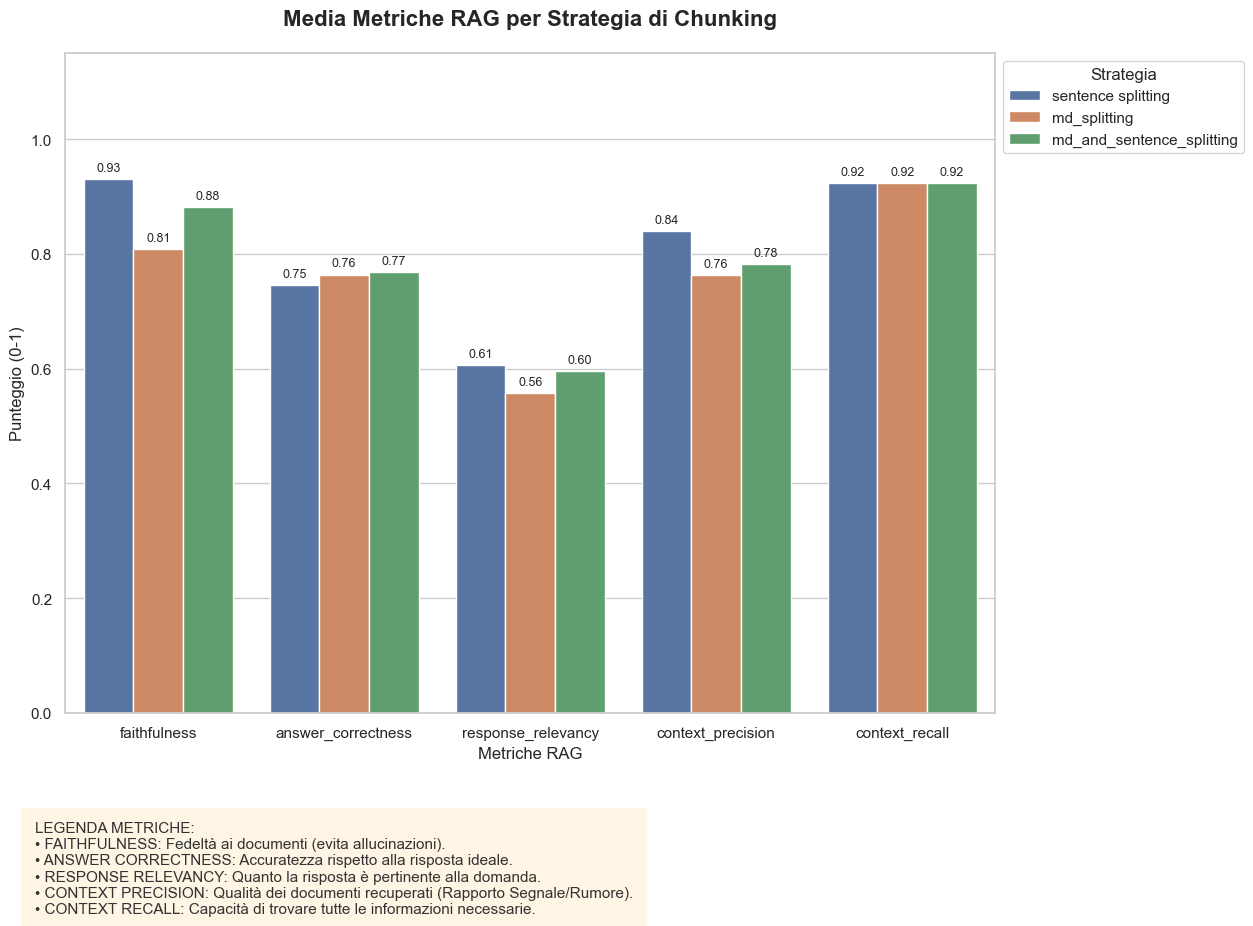

--- TEXTUAL DATA SUMMARY ---
SENTENCE SPLITTING: faithfulness: 0.931, answer_correctness: 0.746, response_relevancy: 0.606, context_precision: 0.840, context_recall: 0.923
MD_SPLITTING: faithfulness: 0.808, answer_correctness: 0.764, response_relevancy: 0.558, context_precision: 0.763, context_recall: 0.923
MD_AND_SENTENCE_SPLITTING: faithfulness: 0.881, answer_correctness: 0.768, response_relevancy: 0.595, context_precision: 0.782, context_recall: 0.923


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# File paths configuration
files = [
    'evals/experiments/from_sentence_splitting_index_results.csv',
    'evals/experiments/from_rag_index_markdown_chunking_results.csv',
    'evals/experiments/from_rag_index_markdown_and_sentence_chunking_results.csv'
]

# Strategy name mapping
name_map = {
    'from_sentence_splitting_index_results': 'sentence splitting',
    'from_rag_index_markdown_chunking_results': 'md_splitting',
    'from_rag_index_markdown_and_sentence_chunking_results': 'md_and_sentence_splitting'
}

metrics = ['faithfulness', 'answer_correctness', 'response_relevancy', 'context_precision', 'context_recall']
results = []

# Data processing loop
for file_path in files:
    raw_name = os.path.basename(file_path).replace('.csv', '')
    label = name_map.get(raw_name, raw_name)
    try:
        df = pd.read_csv(file_path)
        # Calculate mean for each metric
        row = df[metrics].mean().to_dict()
        row['strategy'] = label
        results.append(row)
    except Exception as e:
        print(f"Error processing {label}: {e}")

df_results = pd.DataFrame(results)

# --- CHART CONFIGURATION ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10)) 

# Reshape dataframe for grouped bar chart
df_melted = df_results.melt(id_vars='strategy', value_vars=metrics, var_name='Metric', value_name='Score')

# Create bar plot - Fix: assign strategy to hue to avoid deprecation warning
ax1 = sns.barplot(data=df_melted, x='Metric', y='Score', hue='strategy')

plt.title('Media Metriche RAG per Strategia di Chunking', fontsize=16, pad=20, fontweight='bold')
plt.ylim(0, 1.15)
plt.ylabel('Punteggio (0-1)', fontsize=12)
plt.xlabel('Metriche RAG', fontsize=12)
plt.legend(title='Strategia', bbox_to_anchor=(1, 1), loc='upper left')

# Add value labels on top of each bar
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9)

# --- INTEGRATED TEXT DESCRIPTION INSIDE FIGURE ---
description_text = (
    "LEGENDA METRICHE:\n"
    "• FAITHFULNESS: Fedeltà ai documenti (evita allucinazioni).\n"
    "• ANSWER CORRECTNESS: Accuratezza rispetto alla risposta ideale.\n"
    "• RESPONSE RELEVANCY: Quanto la risposta è pertinente alla domanda.\n"
    "• CONTEXT PRECISION: Qualità dei documenti recuperati (Rapporto Segnale/Rumore).\n"
    "• CONTEXT RECALL: Capacità di trovare tutte le informazioni necessarie."
)

# Position text box at the bottom
plt.figtext(0.1, 0.02, description_text, fontsize=11, color="#333333", 
            bbox={"facecolor":"orange", "alpha":0.1, "pad":10}, 
            horizontalalignment='left')

# Adjust layout to prevent clipping the description
plt.subplots_adjust(bottom=0.22) 
plt.show()

# Simplified text output for LLM analysis
print("--- TEXTUAL DATA SUMMARY ---")
for _, r in df_results.iterrows():
    print(f"{r['strategy'].upper()}: " + ", ".join([f"{m}: {r[m]:.3f}" for m in metrics]))

--- SUMMARY JUDGE PASS COUNT ---
sentence splitting: 11 pass
md splitting: 12 pass
md and sentence splitting: 12 pass


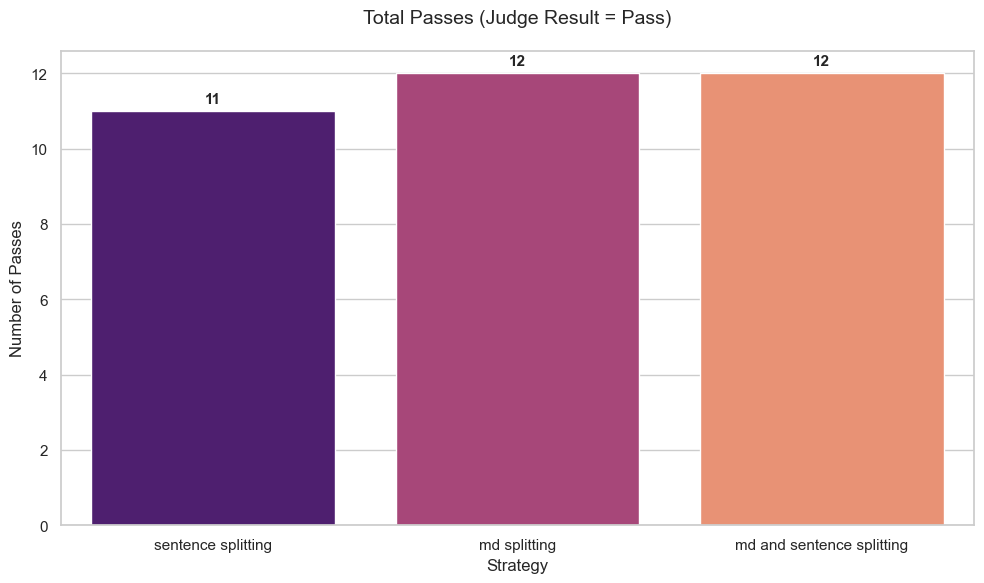

In [10]:
print("--- SUMMARY JUDGE PASS COUNT ---")
for _, r in df_results.iterrows():
    print(f"{r['strategy']}: {int(r['judge_pass_count'])} pass")

plt.figure(figsize=(10, 6))

ax2 = sns.barplot(data=df_results, x='strategy', y='judge_pass_count', 
                  hue='strategy', palette='magma', legend=False)

plt.title('Total Passes (Judge Result = Pass)', fontsize=14, pad=20)
plt.ylabel('Number of Passes')
plt.xlabel('Strategy')

for p in ax2.patches:
    ax2.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 9), textcoords='offset points', 
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()